# Markov-Switching AR Model

This notebook presents the implementation and validation results of the Markov-Switching AR model for regime detection and return forecasting on SPY.

In [1]:
from model_utils import MSARConfig, run_full_msar_pipeline, plot_regime_probabilities

In [2]:
config = MSARConfig(
    ticker="SPY",
    start_date="2019-01-01",
    end_date="2025-01-01",
    train_ratio=0.7,
    val_ratio=0.15,
    k_regimes=2,
    order=1,
    trend="c",
)

outputs = run_full_msar_pipeline(config)

Loading data from cache...


## Best Model Configuration

In [3]:
outputs["best_config"]

{'k_regimes': 2,
 'order': 1,
 'switching_variance': True,
 'trend': 'c',
 'switching_ar': False}

## Hyperparameter Tuning Results

In [4]:
outputs["tuning_table"]

,k_regimes,order,switching_variance,aic,bic,llf,error
0,2,1,True,-6445.883321,-6411.154249,3229.941660,None
1,2,2,True,-6449.537093,-6409.854311,3232.768547,None
2,2,1,False,-6141.617231,-6111.849455,3076.808616,None
3,2,2,False,-6025.481525,-5990.759091,3019.740762,None


## Validation Forecast Metrics

In [5]:
outputs["validation_metrics"]

{'MSE': 5.7166675538702744e-05,
 'MAE': 0.0059447961821535574,
 'RMSE': 0.00756086473485029,
 'Directional_Accuracy': 0.5575221238938053}

## Forecast Comparison

<Axes: title={'center': 'Actual vs Predicted Returns'}>

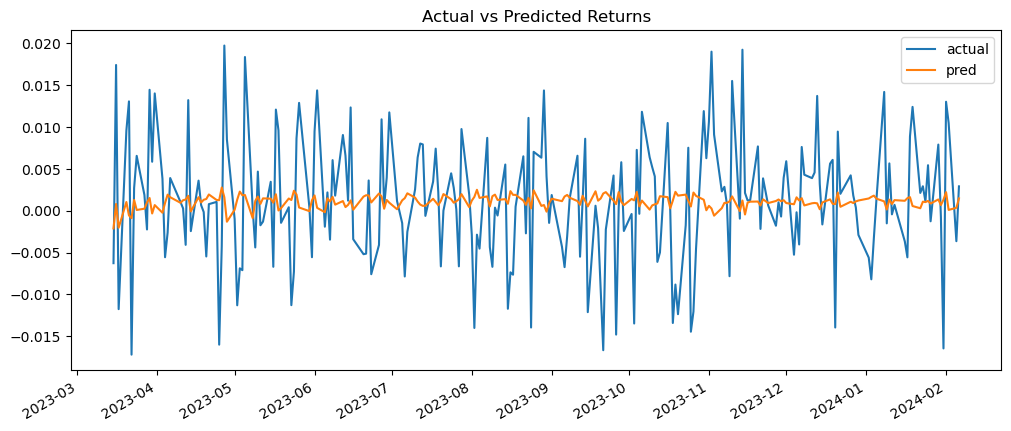

In [6]:
outputs["validation_forecasts"][["actual", "pred"]].plot(
    figsize=(12, 5),
    title="Actual vs Predicted Returns"
)

## Regime Probabilities

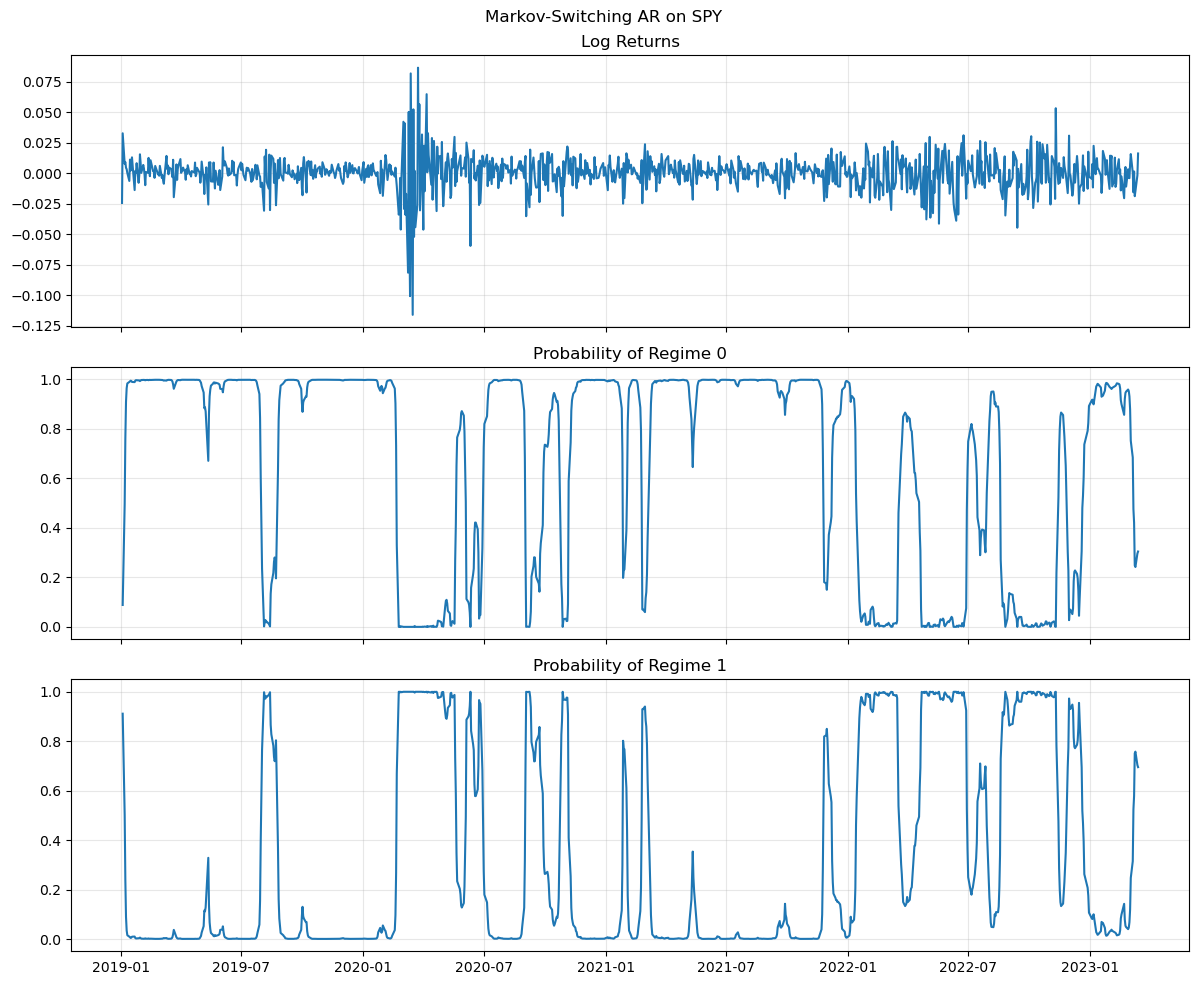

In [7]:
plot_regime_probabilities(
    outputs["best_result"],
    outputs["train"]["return"],
    title="Markov-Switching AR on SPY"
)

## Conclusion

The Markov-Switching AR model captures latent regime changes in ETF returns and provides an interpretable framework for modeling time-varying return dynamics. The regime probability plots help identify different market conditions, while the rolling validation forecasts provide evidence on short-term predictive performance.